**LAB 4**

**CS4082– Machine Learning**

Linear Regression & Its Variants

---




Predicting Continuous Values with Scikit-Learn and Real-World Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print("Dataset shape:", df.shape)
print("\nFeatures:\n", housing.feature_names)
print("\nFirst 5 rows:\n", df.head())
print("\nStatistics:\n", df.describe().round(3))

Dataset shape: (20640, 9)

Features:
 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Statistics:
           MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.097    142

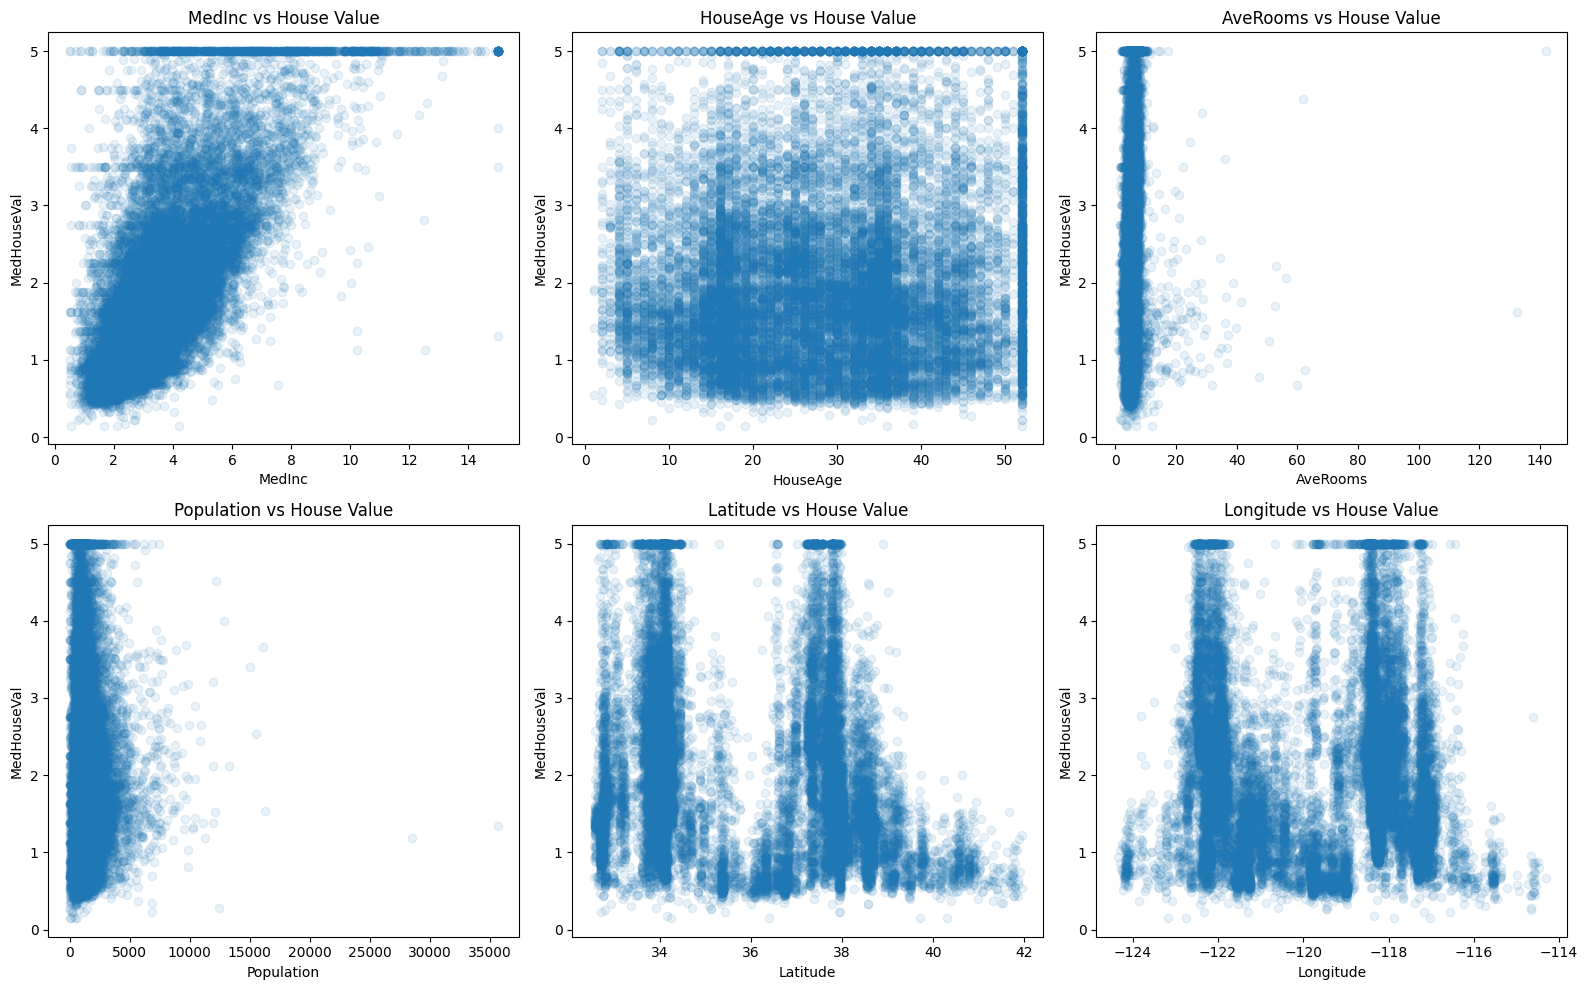

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features = ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'Latitude', 'Longitude']

for ax, feat in zip(axes.flatten(), features):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.1)
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{feat} vs House Value')

plt.tight_layout()
plt.show()

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


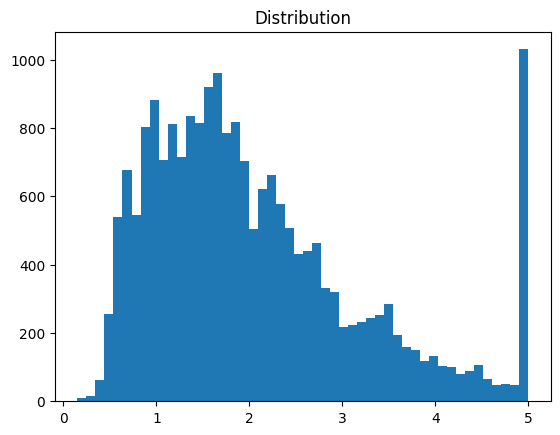

Samples: 20640


In [3]:
# Correlation
corr = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(corr)

# Histogram
plt.hist(df['MedHouseVal'], bins=50)
plt.title("Distribution")
plt.show()

# Number of samples
print("Samples:", df.shape[0])

**TASK 1 :**

The feature with the strongest correlation with the target (MedHouseVal) is **MedInc**, with a correlation value of approximately 0.688, making it the most influential feature.

The distribution of MedHouseVal is not normally distributed. It appears right-skewed, and there is a clear cap at the value of 5.0, indicating that house prices are limited at $500,000 in the dataset.

The dataset contains 20,640 samples, which is considered a sufficiently large dataset for training a reliable machine learning model.


In [4]:
from sklearn.model_selection import train_test_split

# Use only MedInc as the feature
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

Training samples: 16512
Testing samples: 4128


In [5]:
from sklearn.linear_model import LinearRegression

# Train
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Print the learned parameters
print(f'Slope (w1): {model_simple.coef_[0]:.4f}')
print(f'Intercept (w0): {model_simple.intercept_:.4f}')

print(f'\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc + ({model_simple.intercept_:.4f})')

Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc + (0.4446)


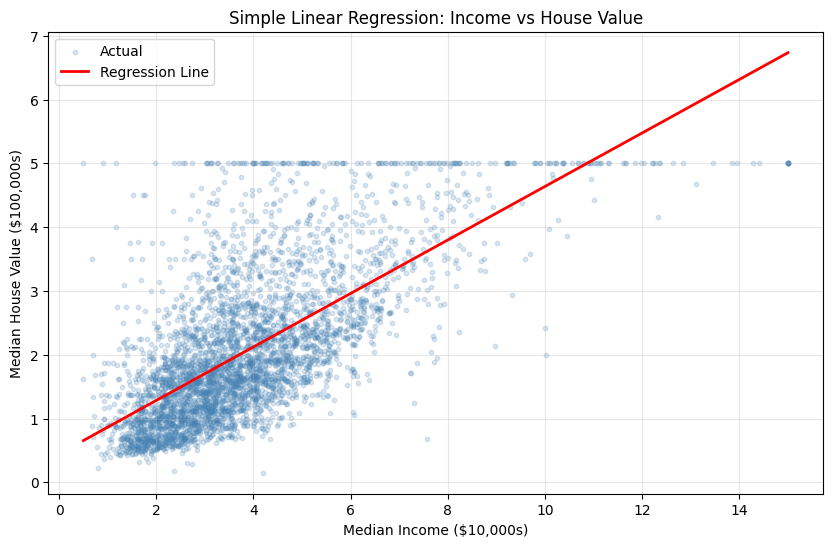

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize: scatter + regression line
plt.figure(figsize=(10, 6))

plt.scatter(X_test, y_test, alpha=0.2, s=10,
            color='steelblue', label='Actual')

# Draw the regression line
x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))

plt.plot(x_line, y_line, color='red', linewidth=2,
         label='Regression Line')

plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [7]:
# Predict a value
print(model_simple.predict([[5.0]]))

[2.54128976]


**TASK 2 :**

The model learned a slope (w1) of 0.4193 and an intercept (w0) of 0.4446.
Therefore, the regression equation is:

y = 0.4193 × MedInc + 0.4446

For a district with a median income of $50,000 (MedInc = 5.0), the predicted house value is:

y = 0.4193 × 5 + 0.4446 = 2.5411 (approximately)

This matches the model prediction value of 2.5413.

When using HouseAge instead of MedInc, the model performs worse because HouseAge has a much weaker correlation with house prices compared to MedInc. Income is a stronger predictor of house value.


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred_simple = model_simple.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print('=== Simple Linear Regression (MedInc only) ===')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f} (error in $100,000s)')
print(f'MAE: {mae:.4f} (error in $100,000s)')
print(f'R^2: {r2:.4f} ({r2*100:.1f}% variance explained)')

=== Simple Linear Regression (MedInc only) ===
MSE: 0.7091
RMSE: 0.8421 (error in $100,000s)
MAE: 0.6299 (error in $100,000s)
R^2: 0.4589 (45.9% variance explained)


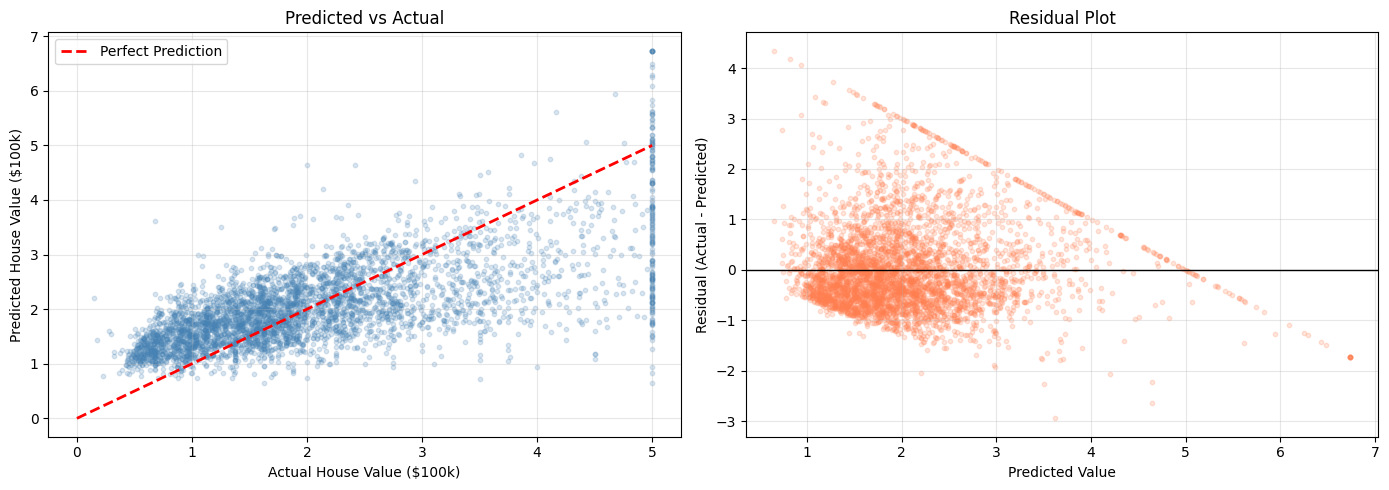

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (errors)
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10, color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**TASK 3 :**

The RMSE value is approximately 0.8421. Since the target variable is measured in units of $100,000  this corresponds to an avarage prediction error of about  $84,210.



From the “Predicted vs Actual” plot, the model struggles more with higher house values, where predictions are more spread out and deviate further from the ideal diagonal line.

The R² value is approximately 0.4589, meaning the model explains about 45.9% of the variance in house prices. This indicates that using a single feature (MedInc) is not sufficient to accurately predict house values, and more features are needed to improve performance.


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Use all features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

# Build pipeline with scaling (good practice!)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# Train
pipe_lr.fit(X_train, y_train)

# Predict
y_pred_multi = pipe_lr.predict(X_test)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print('=== Multiple Linear Regression (all features) ===')
print(f'RMSE: {rmse_multi:.4f}')
print(f'R^2: {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)')

=== Multiple Linear Regression (all features) ===
RMSE: 0.7456
R^2: 0.5758 (57.6% variance explained)


In [11]:
# Extract coefficients
lr_model = pipe_lr.named_steps['lr']
feature_names = df.drop(columns=['MedHouseVal']).columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Feature Importance:")
print(coef_df)

Feature Importance:
      Feature  Coefficient
6    Latitude    -0.896929
7   Longitude    -0.869842
0      MedInc     0.854383
3   AveBedrms     0.339259
2    AveRooms    -0.294410
1    HouseAge     0.122546
5    AveOccup    -0.040829
4  Population    -0.002308


**TASK 4 :**

The top 3 most important features based on the absolute value of coefficients are Latitude, Longitude, and MedInc. These features have the strongest influence on predicting house values.

The bottom 3 least important features are Population, AveOccup, and HouseAge, as they have the smallest impact on the model.

The negative coefficient of Latitude indicates that as we move north (higher latitude), house prices tend to decrease. This reflects geographical patterns in California, where southern coastal areas are generally more expensive.

The “Predicted vs Actual” performance improves compared to the simple model. The R² value increased from about 0.4589 to 0.5758, meaning the model now explains more variance. The RMSE also decreased from 0.8421 to 0.7456, indicating better prediction accuracy. Overall, the multiple regression model performs better than the simple model.


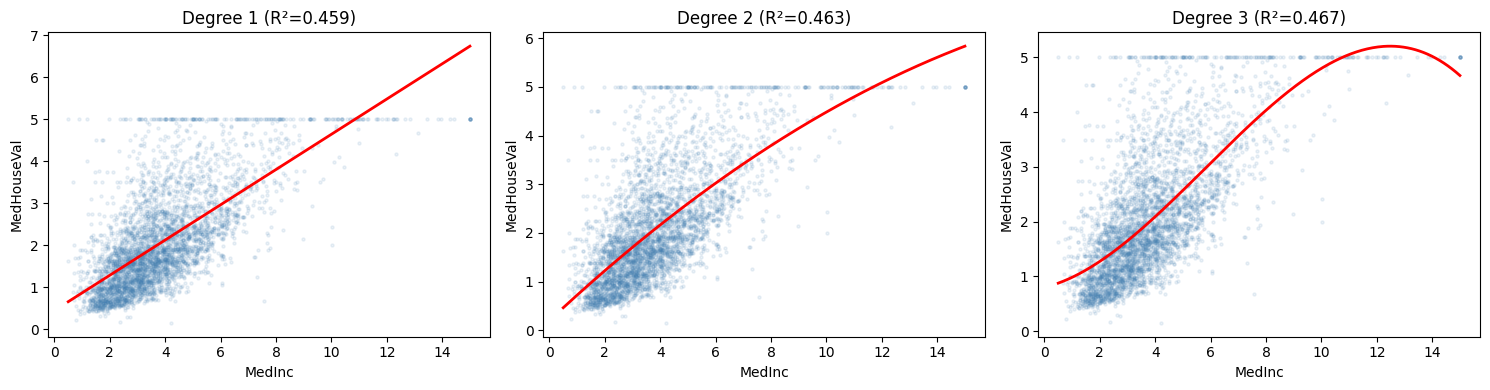

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Use only MedInc
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

# Try degrees 1, 2, 3
results = {}

plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):

    # Build pipeline
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])

    # Train
    pipe_poly.fit(X_train_s, y_train)

    # Predict
    y_pred = pipe_poly.predict(X_test_s)

    # Metrics
    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))

    results[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    # Plot
    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')

    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)

    ax.plot(x_plot, y_plot, color='red', linewidth=2)
    ax.set_title(f'Degree {degree} (R²={r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

In [13]:
print("Polynomial Degree Comparison:")
for deg, metrics in results.items():
    print(f"Degree {deg}: R2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}")

Polynomial Degree Comparison:
Degree 1: R2=0.4589, RMSE=0.8421
Degree 2: R2=0.4633, RMSE=0.8386
Degree 3: R2=0.4671, RMSE=0.8356


**TASK 5 :**

From the plots and results, degree 3 provides the best fit among the three models. It has the highest R² value (0.4671) and the lowest RMSE (0.8356), indicating slightly better performance compared to degrees 1 and 2.

However, although performance improves slightly with higher degrees, the curve for degree 3 starts to show unusual behavior at the edges, especially at higher income values. This suggests the beginning of overfitting.

If we try degree 5, the model will likely continue increasing R² slightly, but it will behave more erratically at the edges, which is a clear sign of overfitting. The model starts to memorize the data instead of learning the general pattern.

For 8 original features, polynomial expansion with degree 3 produces 164 features, which significantly increases model complexity and the risk of overfitting.


In [14]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

# Define models
models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'Ridge (alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),

    'Lasso (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, random_state=42))
    ]),

    'ElasticNet (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ])
}

# Train & evaluate
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R^2':>8}")
print("-" * 50)

results_dict = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    results_dict[name] = {
        'RMSE': rmse_val,
        'MAE': mae_val,
        'R2': r2_val
    }

    print(f"{name:<25} {rmse_val:>8.4f} {mae_val:>8.4f} {r2_val:>8.4f}")

Model                         RMSE      MAE      R^2
--------------------------------------------------
LinearRegression            0.7456   0.5332   0.5758
Ridge (alpha=1.0)           0.7456   0.5332   0.5758
Lasso (alpha=0.01)          0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)     0.7416   0.5341   0.5803


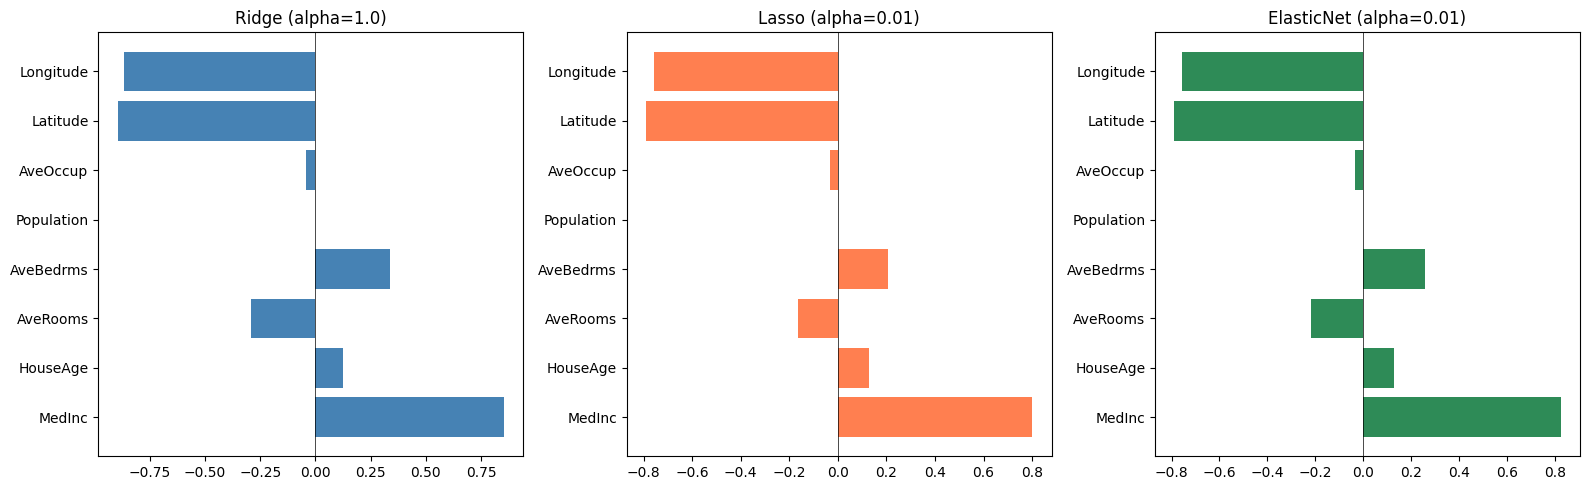

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = [
    'Ridge (alpha=1.0)',
    'Lasso (alpha=0.01)',
    'ElasticNet (alpha=0.01)'
]

colors = ['steelblue', 'coral', 'seagreen']

for ax, name, color in zip(axes, model_names, colors):
    coefs = models[name].named_steps['model'].coef_

    ax.barh(df.drop(columns=['MedHouseVal']).columns, coefs, color=color)
    ax.set_title(name)
    ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [16]:
# Check which features Lasso removed
lasso_coefs = models['Lasso (alpha=0.01)'].named_steps['model'].coef_

print("Lasso selected features:")
for feat, coef in zip(df.drop(columns=['MedHouseVal']).columns, lasso_coefs):
    if coef != 0:
        print(f"{feat}: {coef:.4f}")

Lasso selected features:
MedInc: 0.8010
HouseAge: 0.1271
AveRooms: -0.1628
AveBedrms: 0.2062
AveOccup: -0.0306
Latitude: -0.7901
Longitude: -0.7557


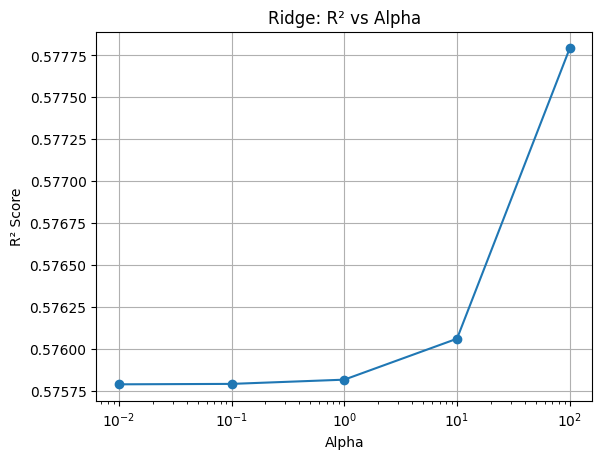

[(0.01, 0.5757879873121596), (0.1, 0.5757905180002312), (1.0, 0.575815742891368), (10.0, 0.5760599032848368), (100.0, 0.5777912763033602)]


In [17]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2_scores.append(r2_score(y_test, y_pred))

# Plot
plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('Ridge: R² vs Alpha')
plt.grid(True)
plt.show()

print(list(zip(alphas, r2_scores)))

In [18]:
lasso_test = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1))
])

lasso_test.fit(X_train, y_train)

coefs = lasso_test.named_steps['model'].coef_

print("Features kept:")
for feat, coef in zip(df.drop(columns=['MedHouseVal']).columns, coefs):
    if coef != 0:
        print(feat, coef)

print("\nRemoved features:")
for feat, coef in zip(df.drop(columns=['MedHouseVal']).columns, coefs):
    if coef == 0:
        print(feat)

Features kept:
MedInc 0.7105977924522479
HouseAge 0.10645269751796298
Latitude -0.011468559971910283

Removed features:
AveRooms
AveBedrms
Population
AveOccup
Longitude


In [19]:
ratios = [0.0, 0.5, 1.0]

for r in ratios:
    model = ElasticNet(alpha=0.01, l1_ratio=r)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    print(f"l1_ratio={r}: R²={r2:.4f}")

l1_ratio=0.0: R²=0.5784
l1_ratio=0.5: R²=0.5803
l1_ratio=1.0: R²=0.5816


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.465e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


**TASK 6 :**

When testing different alpha values for Ridge regression, the R² score remains relatively stable but slightly improves as alpha increases. Even at very large alpha values (e.g., 100), the model does not significantly degrade, but it becomes simpler due to stronger regularization.

For Lasso with alpha = 0.1, several features are removed (their coefficients become zero). The removed features are: AveRooms, AveBedrms, Population, AveOccup, and Longitude. Only a few important features remain, such as MedInc, HouseAge, and Latitude, showing that Lasso performs feature selection.

In ElasticNet, when l1_ratio = 0.0, the model behaves like Ridge regression. When l1_ratio = 1.0, it behaves like Lasso regression. The results show that increasing l1_ratio slightly improves performance, with the best R² achieved at l1_ratio = 1.0.


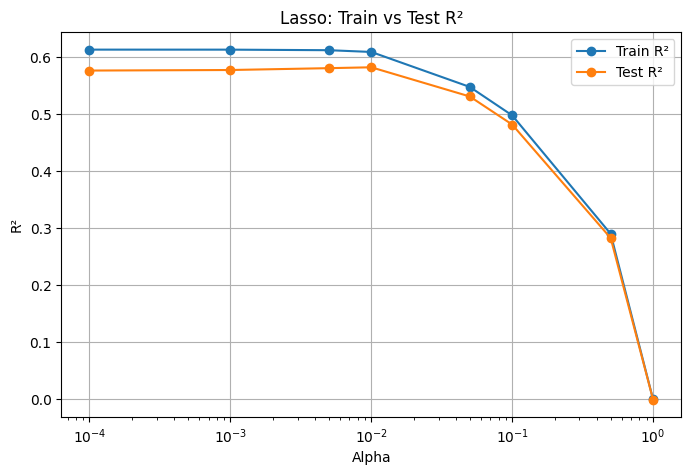

alpha=0.0001: Train R2=0.6126, Test R2=0.5759, Features=8
alpha=0.001: Train R2=0.6125, Test R2=0.5769, Features=8
alpha=0.005: Train R2=0.6115, Test R2=0.5801, Features=7
alpha=0.01: Train R2=0.6085, Test R2=0.5816, Features=7
alpha=0.05: Train R2=0.5472, Test R2=0.5305, Features=4
alpha=0.1: Train R2=0.4974, Test R2=0.4814, Features=3
alpha=0.5: Train R2=0.2900, Test R2=0.2827, Features=1
alpha=1.0: Train R2=0.0000, Test R2=-0.0002, Features=0


In [20]:
from sklearn.linear_model import Lasso

alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_r2 = []
test_r2 = []
num_features = []

for alpha in alphas:

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=alpha, max_iter=10000))
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    # R2
    train_r2.append(r2_score(y_train, y_train_pred))
    test_r2.append(r2_score(y_test, y_test_pred))

    # Count features kept
    coefs = pipe.named_steps['model'].coef_
    num_features.append(sum(coefs != 0))

# Plot R2
plt.figure(figsize=(8,5))
plt.plot(alphas, train_r2, marker='o', label='Train R²')
plt.plot(alphas, test_r2, marker='o', label='Test R²')

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('Lasso: Train vs Test R²')
plt.legend()
plt.grid(True)
plt.show()

# Print results
for a, tr, te, nf in zip(alphas, train_r2, test_r2, num_features):
    print(f"alpha={a}: Train R2={tr:.4f}, Test R2={te:.4f}, Features={nf}")

**TASK 7 :**

From the Lasso alpha tuning experiment, the best test R² is achieved at alpha = 0.01, where the test R² is approximately 0.5816.

As alpha increases, the model starts removing features more aggressively. This behavior becomes noticeable around alpha = 0.05, where the number of features drops significantly from 7 to 4, and continues decreasing further at higher alpha values.

At very large alpha values (e.g., 0.5 and 1.0), the model removes almost all features, leading to severe underfitting and a sharp drop in performance (R² approaches 0).

Overall, smaller alpha values retain more features and provide better performance, while larger alpha values simplify the model too much and reduce accuracy.


In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Rebuild all models on same split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

all_models = {
    'Simple LR (MedInc)': Pipeline([
        ('lr', LinearRegression())
    ]),

    'Multiple LR (all)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),

    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr', LinearRegression())
    ]),

    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),

    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01))
    ]),

    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5))
    ]),
}

# Evaluate
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R^2":>8} {"# Features":>10}')
print('=' * 67)

comparison_data = []

for name, pipe in all_models.items():

    if 'Simple' in name:
        X_tr = X_train[:, [0]]
        X_te = X_test[:, [0]]
    else:
        X_tr, X_te = X_train, X_test

    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)

    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]

    comparison_data.append({
        'Model': name,
        'RMSE': rmse_v,
        'MAE': mae_v,
        'R2': r2_v,
        'Features': n_feat
    })

    print(f'{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>10}')

Model                         RMSE      MAE      R^2 # Features
Simple LR (MedInc)          0.8421   0.6299   0.4589          1
Multiple LR (all)           0.7456   0.5332   0.5758          8
Polynomial (deg=2)          0.6814   0.4670   0.6457         44
Ridge                       0.7456   0.5332   0.5758          8
Lasso                       0.7404   0.5353   0.5816          8
ElasticNet                  0.7416   0.5341   0.5803          8


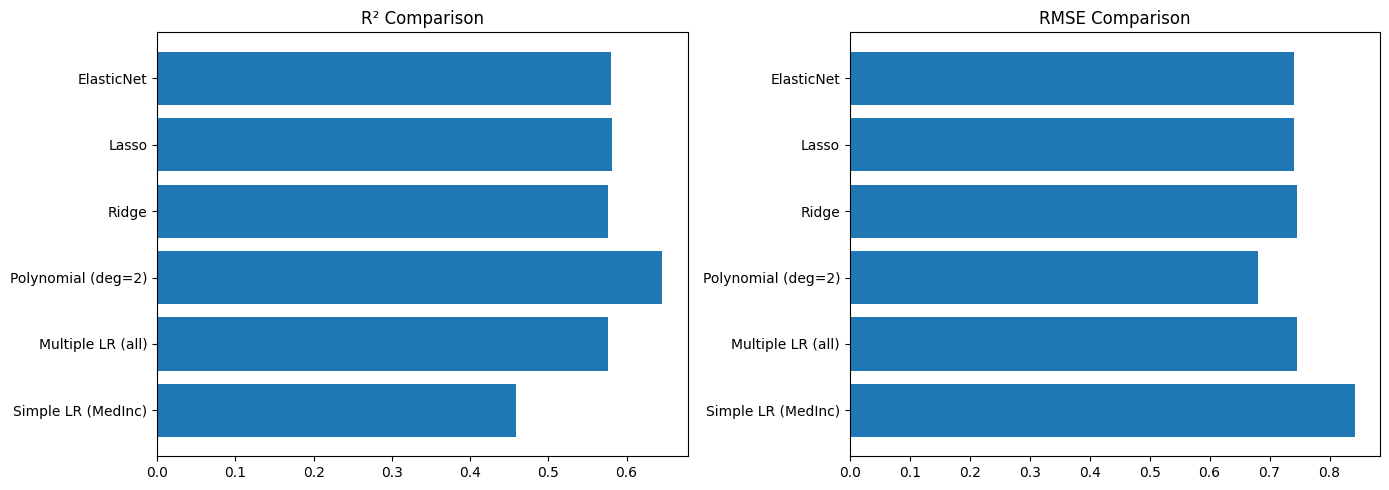

In [22]:
comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2
axes[0].barh(comp_df['Model'], comp_df['R2'])
axes[0].set_title('R² Comparison')

# RMSE
axes[1].barh(comp_df['Model'], comp_df['RMSE'])
axes[1].set_title('RMSE Comparison')

plt.tight_layout()
plt.show()

**TASK 8 :**

The Polynomial (degree 2) model achieved the best performance, with the highest R² of approximately 0.6457 and the lowest RMSE of about 0.6814.

Although the polynomial model provides the best accuracy, it uses 44 features, which significantly increases model complexity. The improvement in R² compared to multiple linear regression (0.5758) is noticeable but may not always justify the added complexity, especially in real-world applications where simplicity and interpretability are important.

If deploying a model in production, Lasso regression (alpha = 0.01) would be a strong choice. It provides good performance (R² ≈ 0.5816) while also performing feature selection, making the model simpler and more interpretable.

Ridge, Lasso, and ElasticNet perform similarly to standard linear regression on this dataset because the dataset does not suffer heavily from overfitting or multicollinearity. As a result, regularization does not dramatically change the model performance, but it still helps in improving stability and feature selection.


In [23]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

cities = np.random.choice(
    ['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
    n, p=[0.30, 0.30, 0.15, 0.15, 0.10])

city_base = {
    'Jeddah': 850,
    'Riyadh': 900,
    'Dammam': 650,
    'Makkah': 1100,
    'Madinah': 750
}

base = np.array([city_base[c] for c in cities], dtype=float)

area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

price = (base
+ 3.5 * area
+ 80 * bedrooms
+ 50 * bathrooms
- 12 * age
+ 15 * floor
+ 100 * has_parking
+ np.random.normal(0, 150, n))

price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    'city': cities,
    'area_sqm': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age,
    'floor': floor,
    'has_parking': has_parking,
    'price_kSAR': price
})

df_saudi.to_csv('saudi_housing.csv', index=False)

print(df_saudi.head())

      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  


In [24]:
# Basic info
print(df_saudi.shape)
print(df_saudi.describe().round(2))

# Correlation (numeric only)
corr = df_saudi.corr(numeric_only=True)['price_kSAR'].sort_values(ascending=False)
print("\nCorrelation with price:\n", corr)

(500, 8)
       area_sqm  bedrooms  bathrooms  age_years   floor  has_parking  \
count    500.00    500.00     500.00      500.0  500.00       500.00   
mean     234.22      3.50       2.45       19.6    7.52         0.71   
std       91.36      1.71       1.13       11.6    3.97         0.46   
min       81.50      1.00       1.00        0.0    1.00         0.00   
25%      153.35      2.00       1.00       10.0    4.00         0.00   
50%      231.00      3.00       2.00       20.0    8.00         1.00   
75%      312.40      5.00       3.00       30.0   11.00         1.00   
max      399.90      6.00       4.00       39.0   14.00         1.00   

       price_kSAR  
count      500.00  
mean      2044.35  
std        452.24  
min        833.80  
25%       1737.22  
50%       2038.55  
75%       2344.07  
max       3326.90  

Correlation with price:
 price_kSAR     1.000000
area_sqm       0.730056
bedrooms       0.300025
bathrooms      0.090535
floor          0.071430
has_parking    0

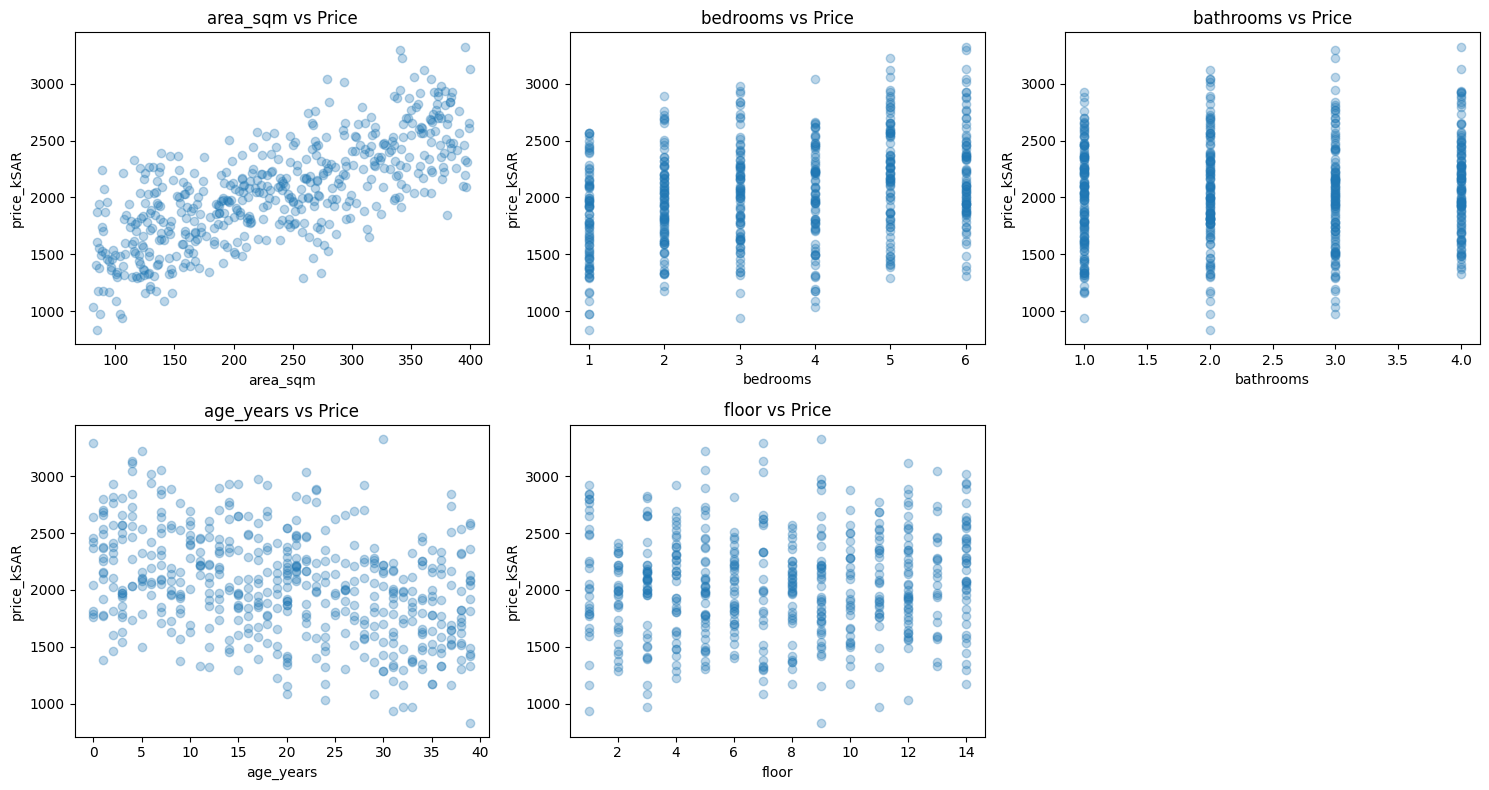

In [25]:
import matplotlib.pyplot as plt

features = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor']

plt.figure(figsize=(15, 8))

for i, feat in enumerate(features):
    plt.subplot(2, 3, i+1)
    plt.scatter(df_saudi[feat], df_saudi['price_kSAR'], alpha=0.3)
    plt.xlabel(feat)
    plt.ylabel('price_kSAR')
    plt.title(f'{feat} vs Price')

plt.tight_layout()
plt.show()

**TASK 9.1 : **

From the correlation analysis, the feature with the strongest positive correlation with house price is **area_sqm**, with a correlation of approximately 0.73. This indicates that larger houses tend to have higher prices.

The scatter plots confirm this observation, as there is a clear upward linear relationship between area and price. Bedrooms also show a moderate positive relationship with price, while bathrooms and floor have weaker effects.

The feature **age_years** has a negative correlation (approximately -0.37), meaning that older properties tend to have lower prices.

Overall, **area_sqm is the most important factor influencing house prices**, which aligns with real-world expectations.


In [27]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features and target
X = df_saudi.drop(columns=['price_kSAR'])
y = df_saudi['price_kSAR']

# Column types
categorical = ['city']
numerical = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']

# Preprocessing
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical),
    ('num', StandardScaler(), numerical)
])

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Use only area
X_area = df_saudi[['area_sqm']]
y = df_saudi['price_kSAR']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_area, y, test_size=0.2, random_state=42)

# Pipeline (scaling + model)
pipe_simple = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# Train
pipe_simple.fit(X_train, y_train)

# Predict
y_pred = pipe_simple.predict(X_test)

# Evaluate
r2_simple = r2_score(y_test, y_pred)
print("Simple Model R²:", r2_simple)

Simple Model R²: 0.4931641174923733


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


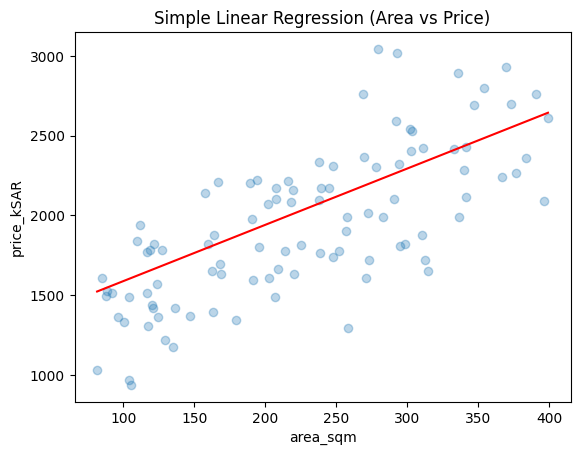

In [29]:
plt.scatter(X_test, y_test, alpha=0.3)

x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = pipe_simple.predict(x_line.reshape(-1, 1))

plt.plot(x_line, y_line, color='red')
plt.xlabel('area_sqm')
plt.ylabel('price_kSAR')
plt.title('Simple Linear Regression (Area vs Price)')
plt.show()

**TASK 9.2 :**

The simple linear regression model using only the area feature achieved an R² score of approximately 0.493.

This indicates that around 49.3% of the variation in house prices can be explained by the area alone. The scatter plot shows a clear positive linear relationship between area and price, and the regression line fits the general trend of the data reasonably well.

However, the spread of the data points around the line suggests that other factors also influence house prices, and using only one feature is not sufficient for accurate predictions.


In [30]:
from sklearn.pipeline import Pipeline

# Split (ALL FEATURES )
X = df_saudi.drop(columns=['price_kSAR'])
y = df_saudi['price_kSAR']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Pipeline (preprocessing + model)
pipe_multi = Pipeline([
    ('preprocess', preprocessor),
    ('lr', LinearRegression())
])

# Train
pipe_multi.fit(X_train, y_train)

# Predict
y_pred_multi = pipe_multi.predict(X_test)

# Evaluate
r2_multi = r2_score(y_test, y_pred_multi)
print("Multiple Model R²:", r2_multi)

Multiple Model R²: 0.8645171715702977



**TASK 9.3 :**

The multiple linear regression model achieved an R² score of approximately 0.8645, which is a significant improvement compared to the simple model (R² ≈ 0.493).

This means that about 86.45% of the variation in house prices is explained when using all available features. The large increase in performance shows that factors such as number of bedrooms, bathrooms, age, floor, parking availability, and city location all play important roles in determining house prices.

This result demonstrates that using multiple features provides a much more accurate and realistic model compared to relying on a single feature like area alone.



In [31]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

for name, model in models.items():

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    print(f"{name} R²: {r2:.4f}")

Ridge R²: 0.8632
Lasso R²: 0.8645
ElasticNet R²: 0.8612


**TASK 9.4 :**

The regularized models achieved very similar performance to the multiple linear regression model.

Ridge regression achieved an R² of approximately 0.8632, Lasso achieved about 0.8645, and ElasticNet achieved around 0.8612.

These results are very close to the multiple linear regression model (R² ≈ 0.8645), indicating that regularization does not significantly improve performance in this case. This suggests that the dataset does not suffer heavily from overfitting or multicollinearity.

However, Lasso is particularly useful because it can perform feature selection by removing less important features, making the model simpler and more interpretable.


In [32]:
# Extract Lasso model
lasso_model = pipe.named_steps['model']

# Get feature names after encoding
feature_names = pipe.named_steps['preprocess'].get_feature_names_out()

# Coefficients
coefs = lasso_model.coef_

# Sort by importance
importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(importance)

             Feature  Coefficient
2   cat__city_Makkah   462.507149
4      num__area_sqm   331.531489
3   cat__city_Riyadh   235.879107
0   cat__city_Jeddah   184.583814
5      num__bedrooms   141.349484
7     num__age_years  -127.566420
1  cat__city_Madinah    85.794924
8         num__floor    73.632189
6     num__bathrooms    53.410695
9   num__has_parking    40.808268


**TASK 9.5 :**

The most important features according to the Lasso model are city_Makkah, area_sqm, and city_Riyadh, followed by city_Jeddah and number of bedrooms.

The feature area_sqm has a strong positive impact on price, which is expected since larger properties are generally more expensive. City-related features are also highly influential, indicating that location plays a major role in determining house prices.

The feature age_years has a negative coefficient, meaning that older properties tend to have lower prices, which is consistent with real-world expectations.

Overall, the selected features are logical and align well with how housing markets typically behave, where size, location, and property condition are key factors.


In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

models = {
    'Simple': pipe_simple,
    'Multiple': pipe_multi,
    'Lasso': Pipeline([
        ('preprocess', preprocessor),
        ('model', Lasso(alpha=0.01))
    ])
}

results = []

for name, model in models.items():

    if name == 'Simple':
        X_tr, X_te = X_train[['area_sqm']], X_test[['area_sqm']]
    else:
        X_tr, X_te = X_train, X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, rmse, mae, r2])

comp = pd.DataFrame(results, columns=['Model', 'RMSE', 'MAE', 'R2'])
print(comp)

      Model        RMSE         MAE        R2
0    Simple  334.666127  276.058355  0.493164
1  Multiple  173.029522  137.301214  0.864517
2     Lasso  173.037356  137.310152  0.864505


### Final Summary

In this task, a full regression analysis was applied to the Saudi housing dataset.

From the exploration step, it was clear that **area_sqm** has the strongest effect on price, while **age_years** has a negative impact. This makes sense since larger and newer houses are usually more expensive.

After preprocessing the data (encoding the city column and scaling numerical features), different models were trained.

The simple model using only area achieved an R² of about 0.49, which shows that one feature alone is not enough. However, when using all features in the multiple linear regression model, the performance improved significantly to around R² = 0.86.

The regularized models (Ridge, Lasso, and ElasticNet) gave very similar results. Among them, Lasso performed slightly better and also helped in identifying the most important features, such as city, area, and number of bedrooms.

Based on the comparison, both Multiple Linear Regression and Lasso achieved the best performance with the lowest error and highest R².

Overall, Lasso is a good choice because it balances accuracy and simplicity by selecting the most useful features, which is important for real-world applications.
